In [ ]:
Telecom.churn PCA + Linear Algebra Full ML Flow
Big Question:
How can matrix algebra, eigen decomposition, and SVD reveal the strongest variance structures in telecom customer behavior to improve churn prediction, segmentation, and strategic business decisions?

In [ ]:
Step 1: Import Required Libraries

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import matrix_rank, norm, eig, svd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [61]:
Step 2: Load Telecom Dataset

<class 'SyntaxError'>: invalid syntax (<ipython-input-61-52fa4791fd3c>, line 1)

In [71]:
df=pd.read_csv("Telecom.churn")

In [ ]:
Step 3: Data Cleaning

In [72]:
# Select features
features = ['Monthly Charge', 'Tenure in Months', 'Total Charges', 'Contract', 'Unlimited Data']

X = df[features].copy()

# Remove missing values
X = X.dropna()

# Remove invalid monthly charges
X = X[X['Monthly Charge'] > 0]

print("Final cleaned shape:", X.shape)

Final cleaned shape: (5423, 5)


In [ ]:
Step 4: Check actual Values Before encoding

In [73]:
# Check actual values before encoding
print("Contract unique values:")
print(X['Contract'].value_counts(dropna=False))

print("\nUnlimited Data unique values:")
print(X['Unlimited Data'].value_counts(dropna=False))

Contract unique values:
Contract
Month-to-Month    3038
Two Year          1223
One Year          1162
Name: count, dtype: int64

Unlimited Data unique values:
Unlimited Data
Yes    4665
No      758
Name: count, dtype: int64


In [59]:
Step 4: Feature Engineering

<class 'SyntaxError'>: invalid syntax (<ipython-input-59-39350cef96d1>, line 1)

In [74]:
# Step 4: Correct Feature Engineering

X_fe = X.copy()

# Clean formatting
X_fe['Contract'] = X_fe['Contract'].astype(str).str.strip()
X_fe['Unlimited Data'] = X_fe['Unlimited Data'].astype(str).str.strip()

# Correct mapping
X_fe['Contract'] = X_fe['Contract'].replace({
    'Month-to-Month': 0,
    'One Year': 1,
    'Two Year': 2
})

X_fe['Unlimited Data'] = X_fe['Unlimited Data'].replace({
    'Yes': 1,
    'No': 0
})

features = [
    'Tenure in Months',
    'Monthly Charge',
    'Total Charges',
    'Contract',
    'Unlimited Data'
]

# Convert all to numeric
for col in features:
    X_fe[col] = pd.to_numeric(X_fe[col], errors='coerce')

print("Before dropna:", X_fe[features].shape)
print(X_fe[features].isna().sum())

X_fe = X_fe[features].dropna()

print("After feature engineering:", X_fe.shape)
print(X_fe.head())

<ipython-input-74-ff0bdcff7027>:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_fe['Contract'] = X_fe['Contract'].replace({
<ipython-input-74-ff0bdcff7027>:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_fe['Unlimited Data'] = X_fe['Unlimited Data'].replace({


Before dropna: (5423, 5)
Tenure in Months    0
Monthly Charge      0
Total Charges       0
Contract            0
Unlimited Data      0
dtype: int64
After feature engineering: (5423, 5)
   Tenure in Months  Monthly Charge  Total Charges  Contract  Unlimited Data
0                 9            65.6         593.30         1               1
2                 4            73.9         280.85         0               1
3                13            98.0        1237.85         0               1
4                 3            83.9         267.40         0               1
5                 9            69.4         571.45         0               1


In [ ]:
Step 5: Standard Scaling

In [77]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fe)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (5423, 5)


In [ ]:
Step 6: Telecom Matrix Structure

In [78]:
print("Matrix Shape:", X_scaled.shape)

Matrix Shape: (5423, 5)


In [ ]:
Step 7: Convert Scaled Data Into DataFrame

In [80]:
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,Tenure in Months,Monthly Charge,Total Charges,Contract,Unlimited Data
0,-0.974151,-0.514548,-0.907835,0.407755,0.403096
1,-1.177583,-0.136075,-1.040393,-0.810568,0.403096
2,-0.811406,0.962867,-0.634383,-0.810568,0.403096
3,-1.218269,0.319918,-1.046099,-0.810568,0.403096
4,-0.974151,-0.341271,-0.917105,-0.810568,0.403096


In [ ]:
Step 8: Matrix Rank

In [81]:
rank = matrix_rank(X_scaled)
print("Matrix Rank:", rank)

Matrix Rank: 5


In [ ]:
Step 9: Frobenius Norm ( The overall Mathematical magnitude (size energy of the entire matrix)

In [82]:
fro_norm = np.linalg.norm(X_scaled, 'fro')

print("Frobenius Norm:", fro_norm)

Frobenius Norm: 164.66632928441672


In [ ]:
Step 10: Feature Means After Scaling

In [83]:
scaled_means = X_scaled_df.mean()

print(scaled_means)

Tenure in Months    3.799694e-17
Monthly Charge     -1.585389e-16
Total Charges       3.144574e-17
Contract           -6.289148e-17
Unlimited Data     -7.861435e-17
dtype: float64


In [ ]:
Step 11: Feature Standard Deviations After Scaling

In [84]:
scaled_stds = X_scaled_df.std()

print(scaled_stds)

Tenure in Months    1.000092
Monthly Charge      1.000092
Total Charges       1.000092
Contract            1.000092
Unlimited Data      1.000092
dtype: float64


In [ ]:
Step 12: Covariance Matrix

In [85]:
cov_matrix = np.cov(X_scaled, rowvar=False)

print(cov_matrix)

[[1.00018443 0.37162742 0.93198872 0.65859997 0.00148907]
 [0.37162742 1.00018443 0.61171643 0.19768785 0.01149695]
 [0.93198872 0.61171643 1.00018443 0.60890423 0.00587638]
 [0.65859997 0.19768785 0.60890423 1.00018443 0.01964011]
 [0.00148907 0.01149695 0.00587638 0.01964011 1.00018443]]


In [ ]:
Step 13: Covariance Matrix as DataFrame

In [86]:
cov_df = pd.DataFrame(cov_matrix, index=features, columns=features)

cov_df

,Tenure in Months,Monthly Charge,Total Charges,Contract,Unlimited Data
Tenure in Months,1.000184,0.371627,0.931989,0.658600,0.001489
Monthly Charge,0.371627,1.000184,0.611716,0.197688,0.011497
Total Charges,0.931989,0.611716,1.000184,0.608904,0.005876
Contract,0.658600,0.197688,0.608904,1.000184,0.019640
Unlimited Data,0.001489,0.011497,0.005876,0.019640,1.000184


In [ ]:
Step 14: Covariance Heatmap Without Seaborn

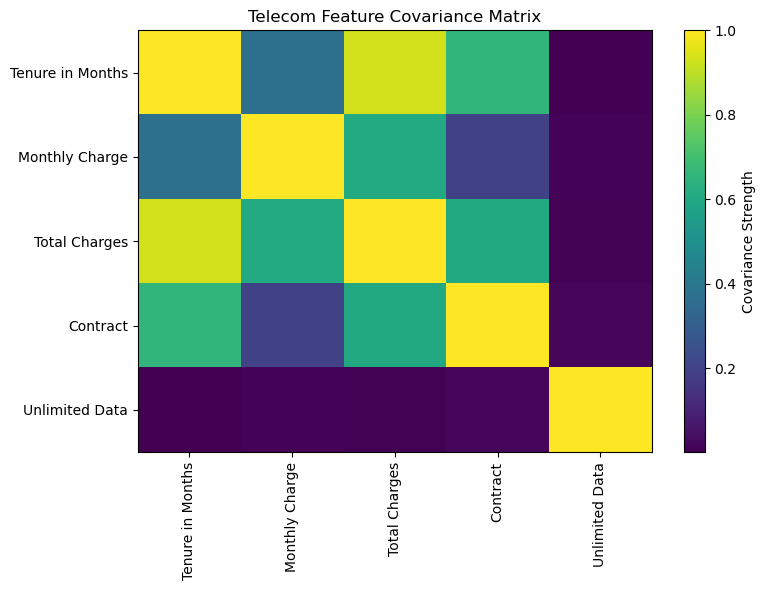

In [87]:
plt.figure(figsize=(8, 6))
plt.imshow(cov_df, aspect='auto')
plt.colorbar(label='Covariance Strength')
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.title("Telecom Feature Covariance Matrix")
plt.tight_layout()
plt.show()

In [ ]:
Step 15: Dot Product Between Two Features

In [96]:
dot_tenure_monthly = np.dot(
    X_scaled_df['Tenure in Months'],
    X_scaled_df['Monthly Charge']
)

print("Dot product between Tenure and Monthly Charge:", dot_tenure_monthly)

Dot product between Tenure and Monthly Charge: 2014.9638653528261


In [ ]:
Step 16: Outer Product Example

In [93]:
outer_example = np.outer(
    X_scaled_df['Tenure in Months'].head(5),
    X_scaled_df['Monthly Charge'].head(5)
)

print(outer_example)

[[ 0.50124797  0.13255726 -0.93797841 -0.31164841  0.33244982]
 [ 0.60592315  0.16023908 -1.13385562 -0.37672968  0.40187502]
 [ 0.41750783  0.11041181 -0.78127664 -0.2595834   0.27690965]
 [ 0.62685819  0.16577545 -1.17303107 -0.38974593  0.41576006]
 [ 0.50124797  0.13255726 -0.93797841 -0.31164841  0.33244982]]


In [ ]:
Step 17: Matrix Multiplication Example

In [94]:
matrix_product = X_scaled.T @ X_scaled

print(matrix_product)

[[5423.         2014.96386535 5053.24284773 3570.92901508    8.07374768]
 [2014.96386535 5423.         3316.72649149 1071.86350223   62.33645134]
 [5053.24284773 3316.72649149 5423.         3301.47873323   31.86171826]
 [3570.92901508 1071.86350223 3301.47873323 5423.          106.48869974]
 [   8.07374768   62.33645134   31.86171826  106.48869974 5423.        ]]


In [ ]:
Step 18: Eigen-Decomposition of Covariance Matrix

In [95]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[2.75660636 0.02802864 0.37097652 0.84490029 1.00041036]

Eigenvectors:
[[-5.59352563e-01 -6.30131972e-01  5.00117759e-01 -1.99085614e-01
  -1.74800756e-02]
 [-3.73047859e-01 -2.27857417e-01 -3.79756054e-01  8.15292166e-01
   5.62439268e-04]
 [-5.84284385e-01  7.42256139e-01  3.16011397e-01  8.73028980e-02
  -1.35123126e-02]
 [-4.54392698e-01  8.33835684e-03 -7.10760070e-01 -5.36660385e-01
   1.65378864e-02]
 [-9.95183891e-03 -9.95279618e-04  2.49897224e-02  6.11864015e-03
   9.99618951e-01]]


In [ ]:
Step 19: Sort Principal Components

In [97]:
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

In [ ]:
Step 20: Explained Variance Ratio

In [98]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

for i, ratio in enumerate(explained_variance_ratio):
    print(f"PC{i+1}: {ratio:.4f}")

PC1: 0.5512
PC2: 0.2000
PC3: 0.1689
PC4: 0.0742
PC5: 0.0056


In [ ]:
Step 21: Scree Plot

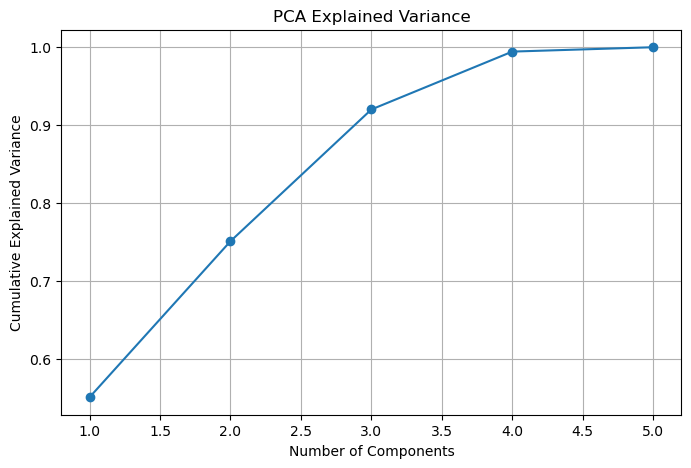

In [99]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(eigenvalues)+1), explained_variance_ratio.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

In [ ]:
Step 22: Principal Component Projection

In [100]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [ ]:
Step 23: PCA Scatter Plot

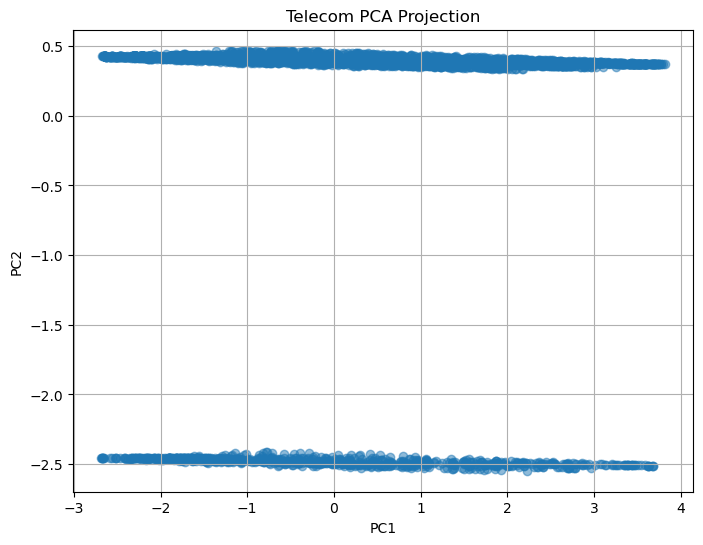

In [101]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Telecom PCA Projection")
plt.grid()
plt.show()

In [ ]:
Step 24: Singular Value Decomposition (SVD)

In [102]:
U, S, VT = svd(X_scaled)

print("U Shape:", U.shape)
print("Singular Values:", S)
print("VT Shape:", VT.shape)

U Shape: (5423, 5423)
Singular Values: [122.25514165  73.64933788  67.68344978  44.84902117  12.32766391]
VT Shape: (5, 5)


In [ ]:
Step 25: SVD Explained Variance

In [103]:
svd_variance = (S**2) / np.sum(S**2)

for i, ratio in enumerate(svd_variance):
    print(f"SVD Component {i+1}: {ratio:.4f}")

SVD Component 1: 0.5512
SVD Component 2: 0.2000
SVD Component 3: 0.1689
SVD Component 4: 0.0742
SVD Component 5: 0.0056


In [ ]:
Step 26: PCA Feature Importance

In [104]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features))],
    index=features
)

print(loadings)

                       PC1       PC2       PC3       PC4       PC5
Tenure in Months  0.559353 -0.017480 -0.199086 -0.500118 -0.630132
Monthly Charge    0.373048  0.000562  0.815292  0.379756 -0.227857
Total Charges     0.584284 -0.013512  0.087303 -0.316011  0.742256
Contract          0.454393  0.016538 -0.536660  0.710760  0.008338
Unlimited Data    0.009952  0.999619  0.006119 -0.024990 -0.000995


In [ ]:
Step 27: Top Variance Drivers

In [105]:
pc1_importance = loadings['PC1'].abs().sort_values(ascending=False)
print(pc1_importance)

Total Charges       0.584284
Tenure in Months    0.559353
Contract            0.454393
Monthly Charge      0.373048
Unlimited Data      0.009952
Name: PC1, dtype: float64


In [ ]:
Step 28: Business Interpretation Table

In [106]:
business_table = pd.DataFrame({
    'Feature': features,
    'PC1 Importance': loadings['PC1'].values,
    'PC2 Importance': loadings['PC2'].values
})

print(business_table)

            Feature  PC1 Importance  PC2 Importance
0  Tenure in Months        0.559353       -0.017480
1    Monthly Charge        0.373048        0.000562
2     Total Charges        0.584284       -0.013512
3          Contract        0.454393        0.016538
4    Unlimited Data        0.009952        0.999619
